In [9]:
'''Data Handling & Linear Algebra'''
import numpy as np
import pandas as pd
import os

'''Visualisation'''
import matplotlib.pyplot as plt
import seaborn as sns

'''Manipulating Data and Model Building'''
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

'''Implementation of Transfer Learning'''
from tensorflow.keras.applications import MobileNetV2

'''Image generation and preprocessing'''
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

'''Result and Performance Analysis'''
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

'''Ignoring Warnings'''
import warnings
warnings.filterwarnings("ignore")

In [10]:
DIR = 'C:/Users/Kartikeya/Desktop/FD_Int/train'

folders = [i for i in os.listdir(DIR)]
folders

['Catla-Body_folder',
 'Grass-Body_folder',
 'Gulfaam-Body_folder',
 'Silver-Body_folder']

In [11]:
label = []
path = []
for dirname,_,filenames in os.walk(DIR):
    for filename in filenames:
        if os.path.splitext(filename)[-1]=='.jpg':
            label.append(os.path.split(dirname)[1])
            path.append(os.path.join(dirname,filename))
            
df = pd.DataFrame(columns=['path','label'])
df['path'] = path
df['label']=label

In [12]:
df

,path,label
0,C:/Users/Kartikeya/Desktop/FD_Int/train\Catla-...,Catla-Body_folder
1,C:/Users/Kartikeya/Desktop/FD_Int/train\Catla-...,Catla-Body_folder
2,C:/Users/Kartikeya/Desktop/FD_Int/train\Catla-...,Catla-Body_folder
3,C:/Users/Kartikeya/Desktop/FD_Int/train\Catla-...,Catla-Body_folder
4,C:/Users/Kartikeya/Desktop/FD_Int/train\Catla-...,Catla-Body_folder
...,...,...
818,C:/Users/Kartikeya/Desktop/FD_Int/train\Silver...,Silver-Body_folder
819,C:/Users/Kartikeya/Desktop/FD_Int/train\Silver...,Silver-Body_folder
820,C:/Users/Kartikeya/Desktop/FD_Int/train\Silver...,Silver-Body_folder
821,C:/Users/Kartikeya/Desktop/FD_Int/train\Silver...,Silver-Body_folder


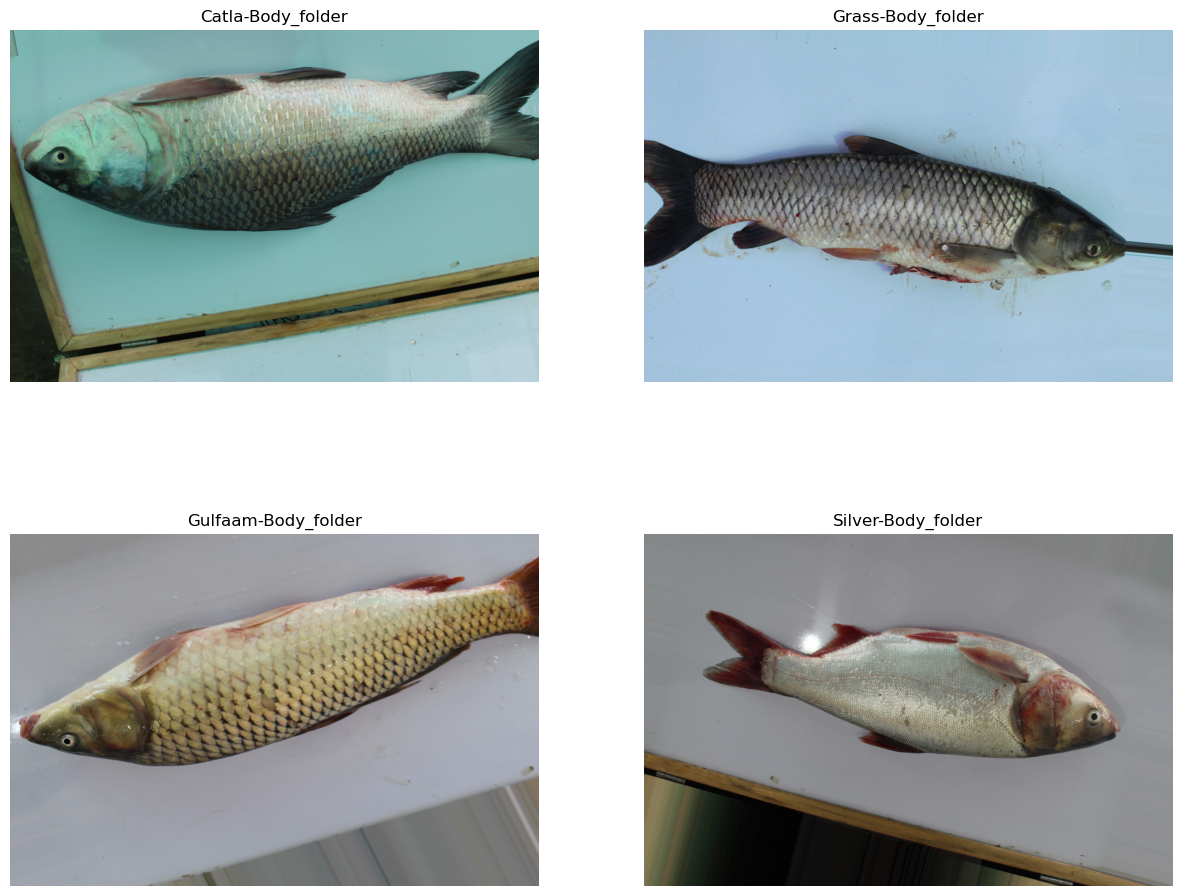

In [13]:
idx = 0
plt.figure(figsize=(15,12))
for i in df['label'].unique():
    plt.subplot(2,2,idx+1)
    plt.imshow(plt.imread(df[df['label']==i].iloc[0,0]))
    plt.title(i)
    plt.axis('off')
    idx+=1

In [14]:
from sklearn.model_selection import train_test_split

train_df,test_df = train_test_split(df,train_size = 0.8,shuffle = True,random_state = 42)

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.imagenet_utils import preprocess_input

# transfer learning
train_generator = ImageDataGenerator(preprocessing_function=preprocess_input,validation_split=0.2)
test_generator = ImageDataGenerator(preprocessing_function=preprocess_input)

In [16]:
train_images = train_generator.flow_from_dataframe(dataframe=train_df, x_col='path', y_col='label', target_size=(224, 224), color_mode='rgb', class_mode='categorical', batch_size=32, shuffle=True, seed=42, subset='training')
val_images = train_generator.flow_from_dataframe(dataframe=train_df, x_col='path', y_col='label', target_size=(224, 224), color_mode='rgb', class_mode='categorical', batch_size=32, shuffle=True, seed=42, subset='validation' )
test_images = test_generator.flow_from_dataframe(dataframe=test_df, x_col='path', y_col='label', target_size=(224, 224), color_mode='rgb', class_mode='categorical', batch_size=32, shuffle=False )

Found 527 validated image filenames belonging to 4 classes.
Found 131 validated image filenames belonging to 4 classes.
Found 165 validated image filenames belonging to 4 classes.


In [17]:
display(train_images.class_indices)
display(val_images.class_indices)
display(test_images.class_indices)

{'Catla-Body_folder': 0,
 'Grass-Body_folder': 1,
 'Gulfaam-Body_folder': 2,
 'Silver-Body_folder': 3}

{'Catla-Body_folder': 0,
 'Grass-Body_folder': 1,
 'Gulfaam-Body_folder': 2,
 'Silver-Body_folder': 3}

{'Catla-Body_folder': 0,
 'Grass-Body_folder': 1,
 'Gulfaam-Body_folder': 2,
 'Silver-Body_folder': 3}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


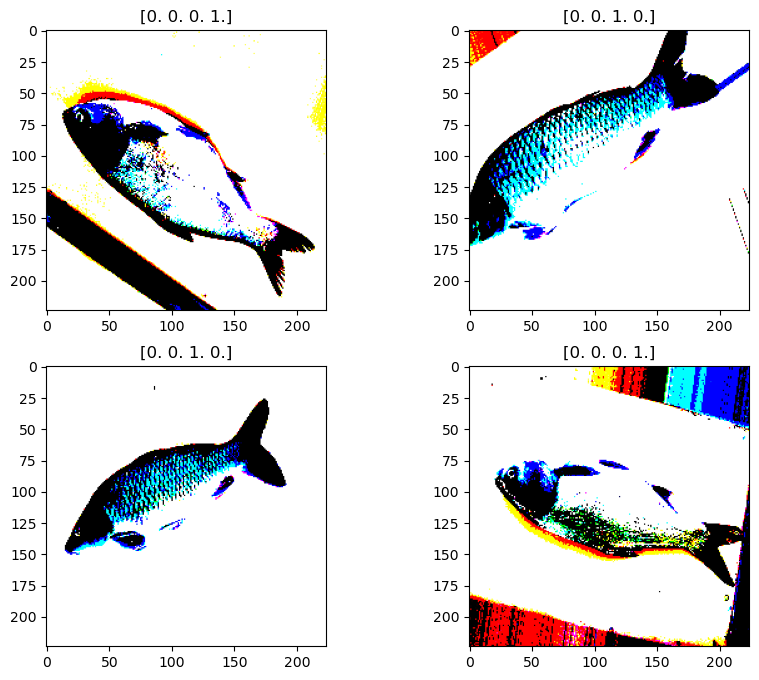

In [18]:
fit, ax= plt.subplots(nrows=2, ncols=2, figsize=(10,8))
ax=ax.flatten()
j=0
for _ in range(4):
    img, label = test_images.next()
    ax[j].imshow(img[0],)
    ax[j].set_title(label[0])
    j=j+1

In [19]:
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

pretrained_model.trainable = False

9406464/9406464 [==============================] - 3s 0us/step


In [20]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)
outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.summary()

model.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])

history = model.fit(train_images,
                    validation_data=val_images,
                    epochs=6)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                                             

 block_3_expand_relu (ReLU)     (None, 56, 56, 144)  0           ['block_3_expand_BN[0][0]']      
                                                                                                  
 block_3_pad (ZeroPadding2D)    (None, 57, 57, 144)  0           ['block_3_expand_relu[0][0]']    
                                                                                                  
 block_3_depthwise (DepthwiseCo  (None, 28, 28, 144)  1296       ['block_3_pad[0][0]']            
 nv2D)                                                                                            
                                                                                                  
 block_3_depthwise_BN (BatchNor  (None, 28, 28, 144)  576        ['block_3_depthwise[0][0]']      
 malization)                                                                                      
                                                                                                  
 block_3_d

 lization)                                                                                        
                                                                                                  
 block_7_expand (Conv2D)        (None, 14, 14, 384)  24576       ['block_6_project_BN[0][0]']     
                                                                                                  
 block_7_expand_BN (BatchNormal  (None, 14, 14, 384)  1536       ['block_7_expand[0][0]']         
 ization)                                                                                         
                                                                                                  
 block_7_expand_relu (ReLU)     (None, 14, 14, 384)  0           ['block_7_expand_BN[0][0]']      
                                                                                                  
 block_7_depthwise (DepthwiseCo  (None, 14, 14, 384)  3456       ['block_7_expand_relu[0][0]']    
 nv2D)    

                                                                                                  
 block_10_depthwise_relu (ReLU)  (None, 14, 14, 384)  0          ['block_10_depthwise_BN[0][0]']  
                                                                                                  
 block_10_project (Conv2D)      (None, 14, 14, 96)   36864       ['block_10_depthwise_relu[0][0]']
                                                                                                  
 block_10_project_BN (BatchNorm  (None, 14, 14, 96)  384         ['block_10_project[0][0]']       
 alization)                                                                                       
                                                                                                  
 block_11_expand (Conv2D)       (None, 14, 14, 576)  55296       ['block_10_project_BN[0][0]']    
                                                                                                  
 block_11_

 block_14_depthwise (DepthwiseC  (None, 7, 7, 960)   8640        ['block_14_expand_relu[0][0]']   
 onv2D)                                                                                           
                                                                                                  
 block_14_depthwise_BN (BatchNo  (None, 7, 7, 960)   3840        ['block_14_depthwise[0][0]']     
 rmalization)                                                                                     
                                                                                                  
 block_14_depthwise_relu (ReLU)  (None, 7, 7, 960)   0           ['block_14_depthwise_BN[0][0]']  
                                                                                                  
 block_14_project (Conv2D)      (None, 7, 7, 160)    153600      ['block_14_depthwise_relu[0][0]']
                                                                                                  
 block_14_

In [21]:
results = model.evaluate(test_images, verbose=0)
print("Test Loss: {:.5f}".format(results[0]))
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

Test Loss: 0.10327
Test Accuracy: 96.97%


In [22]:
pred = model.predict(test_images)
pred=np.argmax(pred,axis=1)

6/6 [==============================] - 40s 6s/step


In [23]:
pred_df=test_df.copy()
labels={}
for l,v in test_images.class_indices.items():
    labels.update({v:l})
pred_df['pred']=pred
pred_df['pred']=pred_df['pred'].apply(lambda x: labels[x])

In [24]:
pred_df=pred_df.reset_index(drop=True)

# Incorrect prediction
pred_df[pred_df['label']!=pred_df['pred']]

,path,label,pred
17,C:/Users/Kartikeya/Desktop/FD_Int/train\Grass-...,Grass-Body_folder,Silver-Body_folder
39,C:/Users/Kartikeya/Desktop/FD_Int/train\Catla-...,Catla-Body_folder,Silver-Body_folder
40,C:/Users/Kartikeya/Desktop/FD_Int/train\Catla-...,Catla-Body_folder,Silver-Body_folder
90,C:/Users/Kartikeya/Desktop/FD_Int/train\Gulfaa...,Gulfaam-Body_folder,Catla-Body_folder
125,C:/Users/Kartikeya/Desktop/FD_Int/train\Gulfaa...,Gulfaam-Body_folder,Catla-Body_folder


Accuracy Score: 0.9696969696969697


<Axes: >

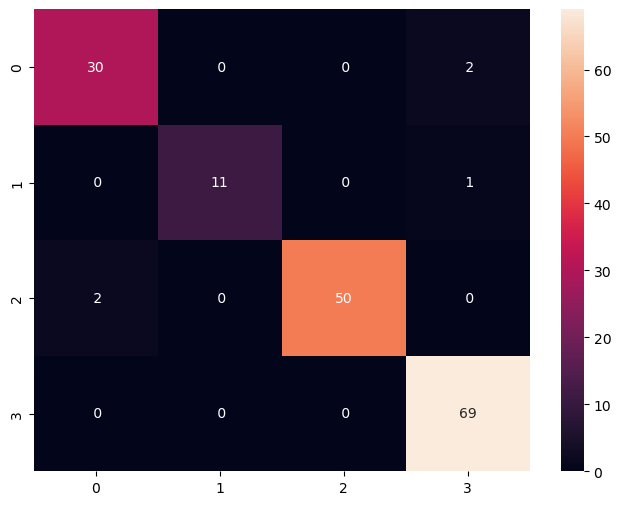

In [25]:
#Checking the accuracy score and creating a Confusion Matrix
print(f"Accuracy Score: {accuracy_score(pred_df['label'],pred_df['pred'])}")
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(pred_df['label'],pred_df['pred']), annot=True, fmt='2d')